# Movement Phase Analysis


## Imports And Configuration

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from emg_lr_segmentation.manual_calibrated_er_mr_lr import atomic_save_annotations, load_mat_raw, normalized_review_annotations
from emg_lr_segmentation.movement_phase import (
    add_lr_latency_outliers,
    assign_phase_bins,
    assign_phase_to_stimuli,
    build_response_by_stim,
    compute_movement_phase,
    detect_cycle_boundaries,
    extract_movement_signal,
    make_emg_envelope,
    make_phase_bins,
    plot_10_epochs_by_phase,
    plot_lr_latency_outliers,
    plot_lr_vs_m_response,
    plot_phase_bin_summary,
    plot_raw_envelope_phase_segment,
    summarize_by_phase_bin,
    validate_filter_parameters,
    validate_phase_alignment,
)

n_phase_bins = 8
phase_bin_labels = np.arange(1, n_phase_bins + 1)

available_response_metric_names = [
    "p2p_amplitude",
    "absolute_peak_amplitude",
    "signed_peak_amplitude",
    "prominence",
    "auc_abs",
    "rms",
    "start_latency_ms",
    "peak_latency_ms",
    "end_latency_ms",
    "duration_ms",
    "amplitude_noise_ratio",
    "p2p_noise_ratio",
]

m_response_metrics = [
    ("middle_p2p_amplitude", "M-response p2p amplitude"),
    ("middle_rms", "M-response RMS"),
    ("middle_peak_latency_ms", "M-response peak latency"),
]

lr_response_metrics = [
    ("late_p2p_amplitude", "LR p2p amplitude"),
    ("late_rms", "LR RMS"),
    ("late_auc_abs", "LR absolute AUC"),
    ("late_peak_latency_ms", "LR peak latency"),
]

latency_outlier_mad_k = 3.0
cycle_duration_flag_range_s = (0.25, 2.0)

movement_phase_config = {
    "channel": "GM Right",
    "emg_band": (30.0, 500.0),
    "envelope_lowpass": 5.0,
    "movement_band": (0.5, 2.5),
    "filter_order": 4,
    "qc_window_s": (100.0, 110.0),
}

mat_path = Path("my_path/my_dir/my_recording.mat")
manual_annotation_path = project_root / "outputs" / "annotations" / "manual_er_mr_lr-annot.fif"
reviewed_metrics_path = project_root / "outputs" / "metrics" / "manual_calibrated_candidates_after_review.csv"
final_annotation_path = project_root / "outputs" / "annotations" / "stimulus_er_mr_lr_manual_calibrated_auto-annot.fif"
open_response_review = True

pd.set_option("display.max_columns", 160)

## Load Recording

In [2]:
if not mat_path.exists():
    raise FileNotFoundError(mat_path)

raw = load_mat_raw(mat_path)
sfreq = float(raw.info["sfreq"])
nyquist = sfreq / 2.0

print("File:", mat_path.name)
print("Raw object:", type(raw).__name__)
print("Sampling frequency, Hz:", sfreq)
print("Nyquist frequency, Hz:", nyquist)
print("Data shape, channels x samples:", (len(raw.ch_names), raw.n_times))
print("Duration, s:", raw.n_times / sfreq)
print("Channels:", raw.ch_names)


File: my_recording.mat
Raw object: RawArray
Sampling frequency, Hz: 4000.0
Nyquist frequency, Hz: 2000.0
Data shape, channels x samples: (7, np.int64(2153600))
Duration, s: 538.4
Channels: ['VL Left', 'TA Left', 'GM left', 'TA Right', 'GM Right', 'Art', 'Art 2']


## Select Movement Reference Channel

In [3]:
channel = movement_phase_config["channel"]
if channel not in raw.ch_names:
    raise ValueError(f"Channel {channel!r} is not present. Available channels: {raw.ch_names}")

raw_emg = raw.get_data(picks=[channel])[0]
time_s = np.arange(raw_emg.size) / sfreq

print("Movement reference channel:", channel)
print("raw_emg shape:", raw_emg.shape)
print("raw_emg finite:", bool(np.isfinite(raw_emg).all()))


raw.copy().plot(
    start=0,
    duration=1.0,
    n_channels=len(raw.ch_names),
    scalings={"emg": 5.16987885},
    title=f"Full recording review: {channel} movement reference",
    block=True,
)


Movement reference channel: GM Right
raw_emg shape: (2153600,)
raw_emg finite: True
Using qt as 2D backend.
Channels marked as bad:
none


## Validate Movement Filter Parameters

In [4]:
validated_filters = validate_filter_parameters(
    sfreq,
    emg_band=movement_phase_config["emg_band"],
    envelope_lowpass=movement_phase_config["envelope_lowpass"],
    movement_band=movement_phase_config["movement_band"],
)
validated_filters


filter_check_df = pd.DataFrame([validated_filters])
display(filter_check_df)


,sfreq,nyquist,emg_band,envelope_lowpass,movement_band
0,4000.0,2000.0,"(30.0, 500.0)",5.0,"(0.5, 2.5)"


## Compute Envelope And Movement Phase

filtered_emg shape: (2153600,)
rectified_emg shape: (2153600,)
envelope shape: (2153600,)
movement_signal shape: (2153600,)
emg_hilbert_amplitude shape: (2153600,)
movement_phase range: -3.141588654144646 3.1415920254052025
cycle boundaries: 822
movement cycles: 821
cycle duration median, s: 0.561
cycle duration mean, s: 0.6534683313032886
cycle duration min, s: 0.14175
cycle duration max, s: 1.9195
cycles outside (0.25, 2.0) s: 8


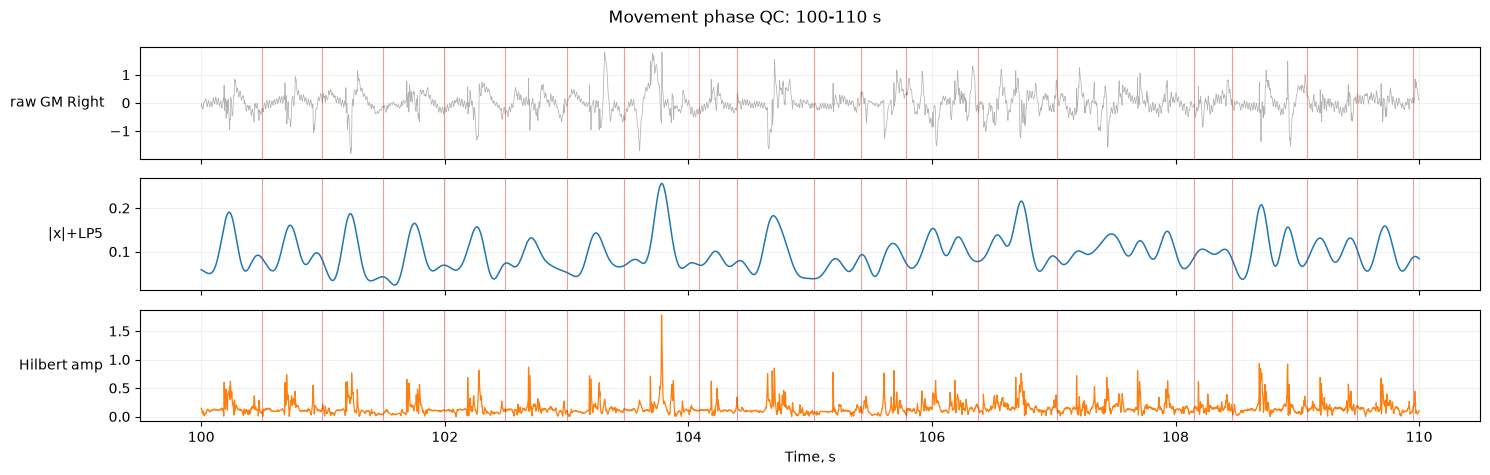

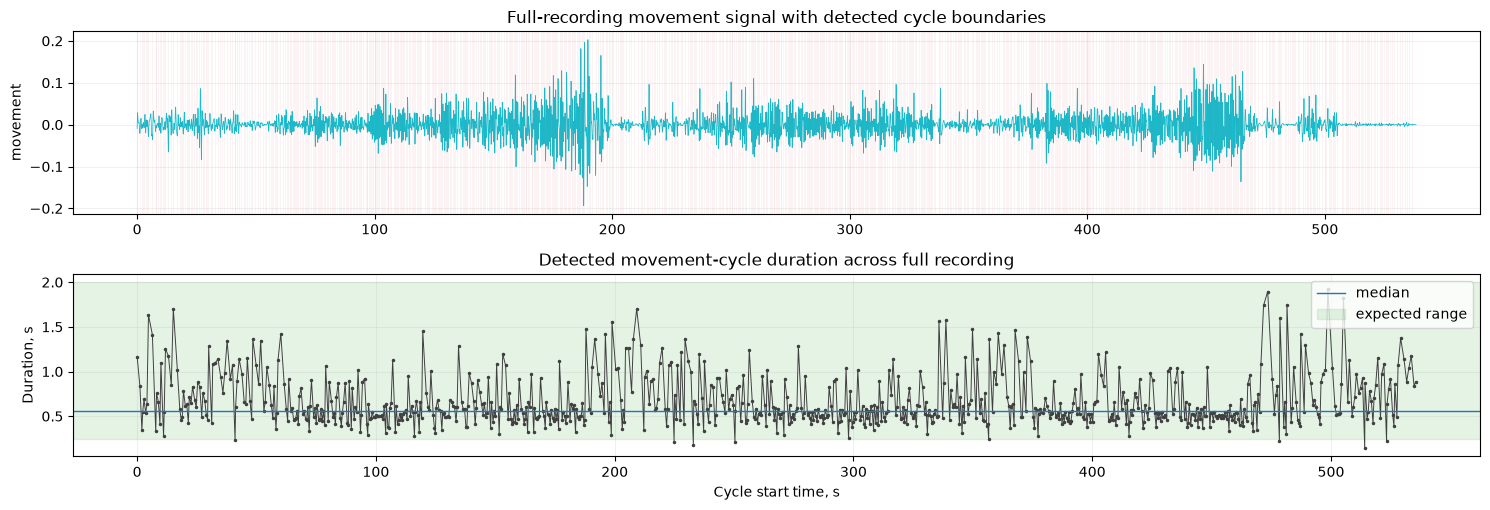

In [5]:
filtered_emg, rectified_emg, envelope = make_emg_envelope(
    raw_emg,
    sfreq,
    emg_band=movement_phase_config["emg_band"],
    envelope_lowpass=movement_phase_config["envelope_lowpass"],
    filter_order=movement_phase_config["filter_order"],
)

movement_signal = extract_movement_signal(
    envelope,
    sfreq,
    movement_band=movement_phase_config["movement_band"],
    filter_order=movement_phase_config["filter_order"],
)

analytic_signal, hilbert_amplitude, movement_phase = compute_movement_phase(movement_signal)
emg_analytic_signal, emg_hilbert_amplitude, _ = compute_movement_phase(filtered_emg)
cycle_boundaries = detect_cycle_boundaries(movement_phase)

print("filtered_emg shape:", filtered_emg.shape)
print("rectified_emg shape:", rectified_emg.shape)
print("envelope shape:", envelope.shape)
print("movement_signal shape:", movement_signal.shape)
print("emg_hilbert_amplitude shape:", emg_hilbert_amplitude.shape)
print("movement_phase range:", float(np.nanmin(movement_phase)), float(np.nanmax(movement_phase)))
print("cycle boundaries:", len(cycle_boundaries))

boundary_times_s = cycle_boundaries / sfreq
cycle_duration_s = np.diff(cycle_boundaries) / sfreq
cycle_start_times_s = boundary_times_s[:-1]
cycle_low_s, cycle_high_s = cycle_duration_flag_range_s
cycle_outlier_count = int(((cycle_duration_s < cycle_low_s) | (cycle_duration_s > cycle_high_s)).sum())

print("movement cycles:", len(cycle_duration_s))
if len(cycle_duration_s):
    print("cycle duration median, s:", float(np.nanmedian(cycle_duration_s)))
    print("cycle duration mean, s:", float(np.nanmean(cycle_duration_s)))
    print("cycle duration min, s:", float(np.nanmin(cycle_duration_s)))
    print("cycle duration max, s:", float(np.nanmax(cycle_duration_s)))
    print(f"cycles outside {cycle_duration_flag_range_s} s:", cycle_outlier_count)


phase_check_start_s, phase_check_stop_s = movement_phase_config["qc_window_s"]
phase_check_stop_s = min(float(phase_check_stop_s), time_s[-1])
phase_check_mask = (time_s >= phase_check_start_s) & (time_s <= phase_check_stop_s)
phase_check_boundaries = boundary_times_s[(boundary_times_s >= phase_check_start_s) & (boundary_times_s <= phase_check_stop_s)]

fig, axes = plt.subplots(3, 1, figsize=(15, 4.8), sharex=True)
axes[0].plot(time_s[phase_check_mask], raw_emg[phase_check_mask], color="0.70", linewidth=0.55)
axes[0].set_ylabel(f"raw {channel}", rotation=0, ha="right", va="center")
axes[1].plot(time_s[phase_check_mask], envelope[phase_check_mask], color="tab:blue", linewidth=1.1)
axes[1].set_ylabel("|x|+LP5", rotation=0, ha="right", va="center")
axes[2].plot(time_s[phase_check_mask], emg_hilbert_amplitude[phase_check_mask], color="tab:orange", linewidth=0.9)
axes[2].set_ylabel("Hilbert amp", rotation=0, ha="right", va="center")
axes[2].set_xlabel("Time, s")
for ax in axes:
    for boundary_s in phase_check_boundaries:
        ax.axvline(boundary_s, color="tab:red", alpha=0.45, linewidth=0.8)
    ax.grid(alpha=0.18)
fig.suptitle(f"Movement phase QC: {phase_check_start_s:g}-{phase_check_stop_s:g} s")
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(15, 5.2), sharex=False)
axes[0].plot(time_s, movement_signal, color="tab:cyan", linewidth=0.55)
for boundary_s in boundary_times_s:
    axes[0].axvline(boundary_s, color="tab:red", alpha=0.06, linewidth=0.6)
axes[0].set_title("Full-recording movement signal with detected cycle boundaries")
axes[0].set_ylabel("movement")
axes[0].grid(alpha=0.18)

axes[1].plot(cycle_start_times_s, cycle_duration_s, color="0.25", marker=".", linestyle="-", linewidth=0.7, markersize=3)
if len(cycle_duration_s):
    axes[1].axhline(np.nanmedian(cycle_duration_s), color="tab:blue", linewidth=1.0, label="median")
axes[1].axhspan(cycle_low_s, cycle_high_s, color="tab:green", alpha=0.12, label="expected range")
axes[1].set_title("Detected movement-cycle duration across full recording")
axes[1].set_xlabel("Cycle start time, s")
axes[1].set_ylabel("Duration, s")
axes[1].grid(alpha=0.18)
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

## Assign Movement Phase To Stimuli

Stimuli: 562
Stimulus sample range: 324743 1861612
Phase bins: 8
Phase bin edges: [-3.142 -2.356 -1.571 -0.785  0.     0.785  1.571  2.356  3.142]
Invalid/missing phase bins: 0
Small phase bins (<50% of median count): [7, 8]


,movement_phase_samples,raw_samples,one_phase_per_raw_sample,stimuli_total,stimulus_samples_integer,stimuli_within_phase_bounds,stimuli_out_of_bounds,stimuli_with_finite_phase,raw_first_samp,sfreq
0,2153600,2153600,True,562,True,562,0,562,0,4000.0


,phase_bin,stimulus_count
0,1,34
1,2,64
2,3,122
3,4,214
4,5,61
5,6,32
6,7,20
7,8,15


,stimulus_index,stimulus_sample,stimulus_time,movement_phase,phase_bin,phase_bin_center,phase_sin,phase_cos
0,0,324743,81.18575,2.040324,7,1.963495,0.891782,-0.452465
1,1,326743,81.68575,-0.656086,4,-0.392699,-0.610020,0.792386
2,2,328743,82.18575,-0.882541,3,-1.178097,-0.772355,0.635191
3,3,330743,82.68575,-1.561701,3,-1.178097,-0.999959,0.009095
4,4,332743,83.18575,-0.850262,3,-1.178097,-0.751453,0.659786


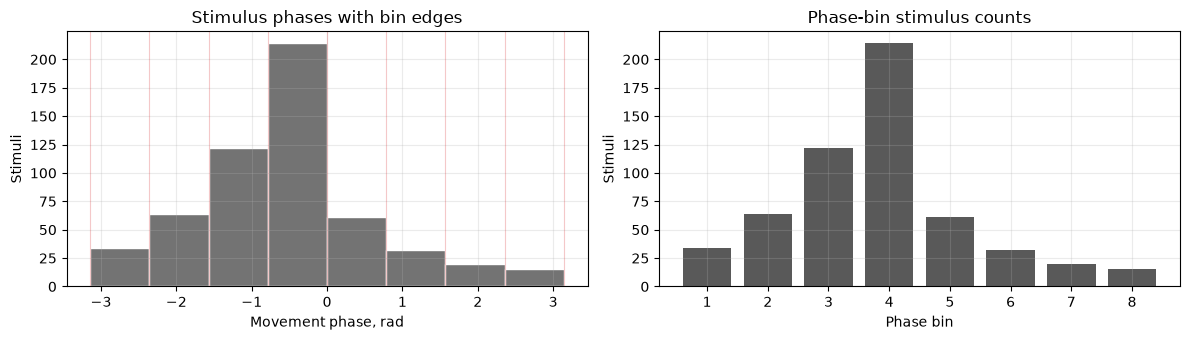

In [6]:
if not manual_annotation_path.exists():
    raise FileNotFoundError(manual_annotation_path)

annotations = mne.read_annotations(manual_annotation_path)
annotation_descriptions = np.asarray(annotations.description, dtype=str)
stim_onsets_s = np.asarray(annotations.onset)[annotation_descriptions == "Stimulus_Auto"]
stim_samples = np.rint(stim_onsets_s * sfreq).astype(int) + raw.first_samp

phase_alignment_summary = validate_phase_alignment(movement_phase, stim_samples, raw, sfreq)
phase_bin_edges, phase_bin_centers = make_phase_bins(n_phase_bins)

stim_phase_dict = assign_phase_to_stimuli(movement_phase, stim_samples, sfreq, first_samp=raw.first_samp)
stim_phases = pd.DataFrame(stim_phase_dict)
stim_phases.insert(0, "stimulus_index", np.arange(len(stim_phases)))
stim_phases = assign_phase_bins(stim_phases, phase_bin_edges)

phase_bin_counts = (
    stim_phases["phase_bin"]
    .value_counts()
    .reindex(phase_bin_labels, fill_value=0)
    .sort_index()
    .rename_axis("phase_bin")
    .rename("stimulus_count")
    .reset_index()
)
small_phase_bins = phase_bin_counts.loc[phase_bin_counts["stimulus_count"] < 0.5 * phase_bin_counts["stimulus_count"].median()]

print("Stimuli:", len(stim_phases))
print("Stimulus sample range:", int(stim_samples.min()), int(stim_samples.max()))
print("Phase bins:", n_phase_bins)
print("Phase bin edges:", np.round(phase_bin_edges, 3))
print("Invalid/missing phase bins:", int(stim_phases["phase_bin"].isna().sum()))
print("Small phase bins (<50% of median count):", small_phase_bins["phase_bin"].tolist())
display(phase_alignment_summary)
display(phase_bin_counts)
display(stim_phases.head())


fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(stim_phases["movement_phase"].dropna(), bins=phase_bin_edges, color="0.45", edgecolor="white")
for edge in phase_bin_edges:
    axes[0].axvline(edge, color="tab:red", alpha=0.25, linewidth=0.8)
axes[0].set_title("Stimulus phases with bin edges")
axes[0].set_xlabel("Movement phase, rad")
axes[0].set_ylabel("Stimuli")
axes[1].bar(phase_bin_counts["phase_bin"], phase_bin_counts["stimulus_count"], color="0.35")
axes[1].set_title("Phase-bin stimulus counts")
axes[1].set_xlabel("Phase bin")
axes[1].set_ylabel("Stimuli")
axes[1].set_xticks(phase_bin_labels)
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Build Per-Stimulus Response Tables

In [7]:
if not final_annotation_path.exists():
    raise FileNotFoundError(final_annotation_path)

if open_response_review:
    mne.viz.set_browser_backend("qt")
    review_raw = raw.copy()
    review_raw.set_annotations(mne.read_annotations(final_annotation_path))
    review_descriptions = pd.Series(review_raw.annotations.description, dtype=str)
    print("Opening editable ER/MR/LR review. Check Stimulus_Auto and edit er_auto/mr_auto/lr_auto spans, then close the browser.")
    print("Annotation counts before review:", review_descriptions.value_counts().to_dict())
    review_raw.plot(
        start=movement_phase_config["qc_window_s"][0],
        duration=5.0,
        n_channels=len(review_raw.ch_names),
        scalings={"emg": 5.16987885},
        title="Editable response review: Stimulus_Auto with er_auto/mr_auto/lr_auto",
        block=True,
    )
    reviewed_annotations, reviewed_metrics = normalized_review_annotations(
        raw,
        review_raw.annotations,
        channel=channel,
    )
    saved_annotation_counts = atomic_save_annotations(reviewed_annotations, final_annotation_path)
    reviewed_metrics_path.parent.mkdir(parents=True, exist_ok=True)
    reviewed_metrics.to_csv(reviewed_metrics_path, index=False)
    print("Saved annotation counts after review:", saved_annotation_counts)
    print("Saved reviewed metrics:", reviewed_metrics_path)
    del review_raw
elif not reviewed_metrics_path.exists():
    raise FileNotFoundError(reviewed_metrics_path)

reviewed_metrics = pd.read_csv(reviewed_metrics_path)
available_metric_columns = [col for col in available_response_metric_names if col in reviewed_metrics.columns]
missing_metric_columns = [col for col in available_response_metric_names if col not in reviewed_metrics.columns]

phase_response_metrics = reviewed_metrics.merge(
    stim_phases[[
        "stimulus_index", "stimulus_sample", "stimulus_time", "movement_phase",
        "phase_bin", "phase_bin_center", "phase_sin", "phase_cos",
    ]],
    on="stimulus_index",
    how="left",
    validate="many_to_one",
)
phase_response_metrics["phase_at_er"] = phase_response_metrics["movement_phase"].where(phase_response_metrics["label"].eq("er"))
phase_response_metrics["phase_at_mr"] = phase_response_metrics["movement_phase"].where(phase_response_metrics["label"].eq("mr"))
phase_response_metrics["phase_at_lr"] = phase_response_metrics["movement_phase"].where(phase_response_metrics["label"].eq("lr"))

response_by_stim = build_response_by_stim(stim_phases, reviewed_metrics, available_metric_columns)
response_by_stim, lr_latency_center_ms, lr_latency_scale_ms = add_lr_latency_outliers(
    response_by_stim,
    value_col="late_peak_latency_ms",
    mad_k=latency_outlier_mad_k,
)
response_by_phase_bin = summarize_by_phase_bin(response_by_stim, available_metric_columns, n_phase_bins)

print("Reviewed response rows:", len(reviewed_metrics))
print("Reviewed stimuli:", reviewed_metrics["stimulus_index"].nunique())
print("Rows with movement phase:", int(phase_response_metrics["movement_phase"].notna().sum()))
print("Available metrics:", available_metric_columns)
print("Missing listed metrics:", missing_metric_columns)
print("LR latency median, ms:", lr_latency_center_ms)
print("LR latency scaled MAD, ms:", lr_latency_scale_ms)
print("LR latency outliers:", int(response_by_stim["late_latency_outlier"].sum()))

response_by_stim.head()



Opening editable ER/MR/LR review. Check Stimulus_Auto and edit er_auto/mr_auto/lr_auto spans, then close the browser.
Annotation counts before review: {'Stimulus_Auto': 562, 'lr_auto': 54, 'er_auto': 30, 'mr_auto': 30, 'BAD boundary': 3, 'EDGE boundary': 3}
Channels marked as bad:
none
Saved annotation counts after review: {'Stimulus_Auto': 562, 'lr_auto': 54, 'er_auto': 30, 'mr_auto': 30, 'BAD boundary': 3, 'EDGE boundary': 3}
Saved reviewed metrics: /Users/sofiaefimochkina/Documents/lab/emg-lr-segmentation/outputs/metrics/manual_calibrated_candidates_after_review.csv
Reviewed response rows: 114
Reviewed stimuli: 30
Rows with movement phase: 114
Available metrics: ['p2p_amplitude', 'absolute_peak_amplitude', 'signed_peak_amplitude', 'prominence', 'auc_abs', 'rms', 'start_latency_ms', 'peak_latency_ms', 'end_latency_ms', 'duration_ms', 'amplitude_noise_ratio', 'p2p_noise_ratio']
Missing listed metrics: []
LR latency median, ms: 34.49200000002861
LR latency scaled MAD, ms: 11.6621316000

,stimulus_id,stimulus_index,stimulus_sample,stimulus_time_s,movement_phase,phase_bin,phase_bin_center,phase_sin,phase_cos,early_p2p_amplitude,early_absolute_peak_amplitude,early_signed_peak_amplitude,early_prominence,early_auc_abs,early_rms,early_start_latency_ms,early_peak_latency_ms,early_end_latency_ms,early_duration_ms,early_amplitude_noise_ratio,early_p2p_noise_ratio,early_start_s,early_end_s,early_annotation_onset_s,early_component_rank,early_present,middle_p2p_amplitude,middle_absolute_peak_amplitude,middle_signed_peak_amplitude,middle_prominence,middle_auc_abs,middle_rms,middle_start_latency_ms,middle_peak_latency_ms,middle_end_latency_ms,middle_duration_ms,middle_amplitude_noise_ratio,middle_p2p_noise_ratio,middle_start_s,middle_end_s,middle_annotation_onset_s,middle_component_rank,middle_present,late_p2p_amplitude,late_absolute_peak_amplitude,late_signed_peak_amplitude,late_prominence,late_auc_abs,late_rms,late_start_latency_ms,late_peak_latency_ms,late_end_latency_ms,late_duration_ms,late_amplitude_noise_ratio,late_p2p_noise_ratio,late_start_s,late_end_s,late_annotation_onset_s,late_component_rank,late_present,early_count,middle_count,late_count,phase_at_er,phase_at_mr,phase_at_lr,late_latency_robust_z,late_latency_outlier
0,0,0,324743,81.18575,2.040324,7,1.963495,0.891782,-0.452465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0,0,0,NaN,NaN,NaN,NaN,False
1,1,1,326743,81.68575,-0.656086,4,-0.392699,-0.610020,0.792386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0,0,0,NaN,NaN,NaN,NaN,False
2,2,2,328743,82.18575,-0.882541,3,-1.178097,-0.772355,0.635191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0,0,0,NaN,NaN,NaN,NaN,False
3,3,3,330743,82.68575,-1.561701,3,-1.178097,-0.999959,0.009095,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0,0,0,NaN,NaN,NaN,NaN,False
4,4,4,332743,83.18575,-0.850262,3,-1.178097,-0.751453,0.659786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0,0,0,NaN,NaN,NaN,NaN,False


## Validation Summary

In [8]:
response_window_summary = (
    reviewed_metrics.groupby("label")
    .agg(
        response_rows=("label", "size"),
        stimulus_count=("stimulus_index", "nunique"),
        start_min_ms=("start_latency_ms", "min"),
        start_median_ms=("start_latency_ms", "median"),
        start_max_ms=("start_latency_ms", "max"),
        peak_median_ms=("peak_latency_ms", "median"),
        end_min_ms=("end_latency_ms", "min"),
        end_median_ms=("end_latency_ms", "median"),
        end_max_ms=("end_latency_ms", "max"),
        duration_median_ms=("duration_ms", "median"),
    )
    .round(4)
)

isi_ms = np.diff(stim_samples) / sfreq * 1000
cycle_duration_s = np.diff(cycle_boundaries) / sfreq
reviewed_end_by_stim = reviewed_metrics.groupby("stimulus_index")["end_latency_ms"].max()
reviewed_common = reviewed_end_by_stim.index[reviewed_end_by_stim.index < len(stim_onsets_s) - 1]
next_isi_for_reviewed_ms = (stim_onsets_s[reviewed_common + 1] - stim_onsets_s[reviewed_common]) * 1000
reviewed_overlap_next = reviewed_end_by_stim.loc[reviewed_common].to_numpy() > next_isi_for_reviewed_ms

timing_delta_s = phase_response_metrics["stimulus_s"] - phase_response_metrics["stimulus_time"]
cycle_low_s, cycle_high_s = cycle_duration_flag_range_s
implausible_cycles = cycle_duration_s[(cycle_duration_s < cycle_low_s) | (cycle_duration_s > cycle_high_s)]

validation_summary = pd.DataFrame([{
    "stimuli_total": len(stim_phases),
    "valid_movement_phase": int(stim_phases["movement_phase"].notna().sum()),
    "excluded_invalid_phase": int(stim_phases["movement_phase"].isna().sum()),
    "phase_bins": n_phase_bins,
    "reviewed_response_rows": len(reviewed_metrics),
    "reviewed_stimuli": int(reviewed_metrics["stimulus_index"].nunique()),
    "median_cycle_duration_s": float(np.nanmedian(cycle_duration_s)),
    "mean_cycle_duration_s": float(np.nanmean(cycle_duration_s)),
    "min_cycle_duration_s": float(np.nanmin(cycle_duration_s)),
    "max_cycle_duration_s": float(np.nanmax(cycle_duration_s)),
    "cycles_flagged_for_inspection": int(len(implausible_cycles)),
    "median_isi_ms": float(np.nanmedian(isi_ms)),
    "mean_isi_ms": float(np.nanmean(isi_ms)),
    "early_duration_median_ms": float(response_window_summary.loc["er", "duration_median_ms"]) if "er" in response_window_summary.index else np.nan,
    "middle_duration_median_ms": float(response_window_summary.loc["mr", "duration_median_ms"]) if "mr" in response_window_summary.index else np.nan,
    "late_duration_median_ms": float(response_window_summary.loc["lr", "duration_median_ms"]) if "lr" in response_window_summary.index else np.nan,
    "late_window_overlaps_next_stimulus": bool(reviewed_overlap_next.any()) if len(reviewed_common) else False,
    "overlapping_reviewed_stimuli": int(reviewed_overlap_next.sum()) if len(reviewed_common) else 0,
    "max_abs_timing_delta_s": float(timing_delta_s.abs().max()),
}])

print("AUC definition currently used: absolute AUC, np.trapezoid(np.abs(segment), time_ms)")
print("RMS definition currently used: sqrt(mean(segment**2))")
print("Latency reference: stimulus onset")
print("Latency note: variation is not automatically artifact; robust outliers are highlighted for waveform inspection.")
display(validation_summary)
display(response_window_summary)
display(response_by_phase_bin)



AUC definition currently used: absolute AUC, np.trapezoid(np.abs(segment), time_ms)
RMS definition currently used: sqrt(mean(segment**2))
Latency reference: stimulus onset
Latency note: variation is not automatically artifact; robust outliers are highlighted for waveform inspection.


,stimuli_total,valid_movement_phase,excluded_invalid_phase,phase_bins,reviewed_response_rows,reviewed_stimuli,median_cycle_duration_s,mean_cycle_duration_s,min_cycle_duration_s,max_cycle_duration_s,cycles_flagged_for_inspection,median_isi_ms,mean_isi_ms,early_duration_median_ms,middle_duration_median_ms,late_duration_median_ms,late_window_overlaps_next_stimulus,overlapping_reviewed_stimuli,max_abs_timing_delta_s
0,562,562,0,8,114,30,0.561,0.653468,0.14175,1.9195,8,500.0,684.879234,3.0,2.5,4.125,False,0,0.000013


,response_rows,stimulus_count,start_min_ms,start_median_ms,start_max_ms,peak_median_ms,end_min_ms,end_median_ms,end_max_ms,duration_median_ms
label,,,,,,,,,,
er,30,30,11.240,12.0065,14.505,13.5085,12.503,15.0110,16.755,3.000
lr,54,30,20.755,32.3790,55.254,34.2435,25.255,35.6215,56.755,4.125
mr,30,30,16.254,17.2620,18.490,18.5050,18.004,20.0040,20.505,2.500


,phase_bin,total_stim_count,early_p2p_amplitude_count,early_p2p_amplitude_mean,early_p2p_amplitude_median,early_p2p_amplitude_std,early_absolute_peak_amplitude_count,early_absolute_peak_amplitude_mean,early_absolute_peak_amplitude_median,early_absolute_peak_amplitude_std,early_signed_peak_amplitude_count,early_signed_peak_amplitude_mean,early_signed_peak_amplitude_median,early_signed_peak_amplitude_std,early_prominence_count,early_prominence_mean,early_prominence_median,early_prominence_std,early_auc_abs_count,early_auc_abs_mean,early_auc_abs_median,early_auc_abs_std,early_rms_count,early_rms_mean,early_rms_median,early_rms_std,early_start_latency_ms_count,early_start_latency_ms_mean,early_start_latency_ms_median,early_start_latency_ms_std,early_peak_latency_ms_count,early_peak_latency_ms_mean,early_peak_latency_ms_median,early_peak_latency_ms_std,early_end_latency_ms_count,early_end_latency_ms_mean,early_end_latency_ms_median,early_end_latency_ms_std,early_duration_ms_count,early_duration_ms_mean,early_duration_ms_median,early_duration_ms_std,early_amplitude_noise_ratio_count,early_amplitude_noise_ratio_mean,early_amplitude_noise_ratio_median,early_amplitude_noise_ratio_std,early_p2p_noise_ratio_count,early_p2p_noise_ratio_mean,early_p2p_noise_ratio_median,early_p2p_noise_ratio_std,middle_p2p_amplitude_count,middle_p2p_amplitude_mean,middle_p2p_amplitude_median,middle_p2p_amplitude_std,middle_absolute_peak_amplitude_count,middle_absolute_peak_amplitude_mean,middle_absolute_peak_amplitude_median,middle_absolute_peak_amplitude_std,middle_signed_peak_amplitude_count,middle_signed_peak_amplitude_mean,middle_signed_peak_amplitude_median,middle_signed_peak_amplitude_std,middle_prominence_count,middle_prominence_mean,middle_prominence_median,middle_prominence_std,middle_auc_abs_count,middle_auc_abs_mean,middle_auc_abs_median,middle_auc_abs_std,middle_rms_count,middle_rms_mean,middle_rms_median,middle_rms_std,middle_start_latency_ms_count,middle_start_latency_ms_mean,middle_start_latency_ms_median,middle_start_latency_ms_std,middle_peak_latency_ms_count,middle_peak_latency_ms_mean,middle_peak_latency_ms_median,middle_peak_latency_ms_std,middle_end_latency_ms_count,middle_end_latency_ms_mean,middle_end_latency_ms_median,middle_end_latency_ms_std,middle_duration_ms_count,middle_duration_ms_mean,middle_duration_ms_median,middle_duration_ms_std,middle_amplitude_noise_ratio_count,middle_amplitude_noise_ratio_mean,middle_amplitude_noise_ratio_median,middle_amplitude_noise_ratio_std,middle_p2p_noise_ratio_count,middle_p2p_noise_ratio_mean,middle_p2p_noise_ratio_median,middle_p2p_noise_ratio_std,late_p2p_amplitude_count,late_p2p_amplitude_mean,late_p2p_amplitude_median,late_p2p_amplitude_std,late_absolute_peak_amplitude_count,late_absolute_peak_amplitude_mean,late_absolute_peak_amplitude_median,late_absolute_peak_amplitude_std,late_signed_peak_amplitude_count,late_signed_peak_amplitude_mean,late_signed_peak_amplitude_median,late_signed_peak_amplitude_std,late_prominence_count,late_prominence_mean,late_prominence_median,late_prominence_std,late_auc_abs_count,late_auc_abs_mean,late_auc_abs_median,late_auc_abs_std,late_rms_count,late_rms_mean,late_rms_median,late_rms_std,late_start_latency_ms_count,late_start_latency_ms_mean,late_start_latency_ms_median,late_start_latency_ms_std,late_peak_latency_ms_count,late_peak_latency_ms_mean,late_peak_latency_ms_median,late_peak_latency_ms_std,late_end_latency_ms_count,late_end_latency_ms_mean,late_end_latency_ms_median,late_end_latency_ms_std,late_duration_ms_count,late_duration_ms_mean,late_duration_ms_median,late_duration_ms_std,late_amplitude_noise_ratio_count,late_amplitude_noise_ratio_mean,late_amplitude_noise_ratio_median,late_amplitude_noise_ratio_std,late_p2p_noise_ratio_count,late_p2p_noise_ratio_mean,late_p2p_noise_ratio_median,late_p2p_noise_ratio_std,late_response_count,late_response_fraction
0,1,34,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,

## QC Figure: Raw EMG, Envelope, Movement Signal, And Phase

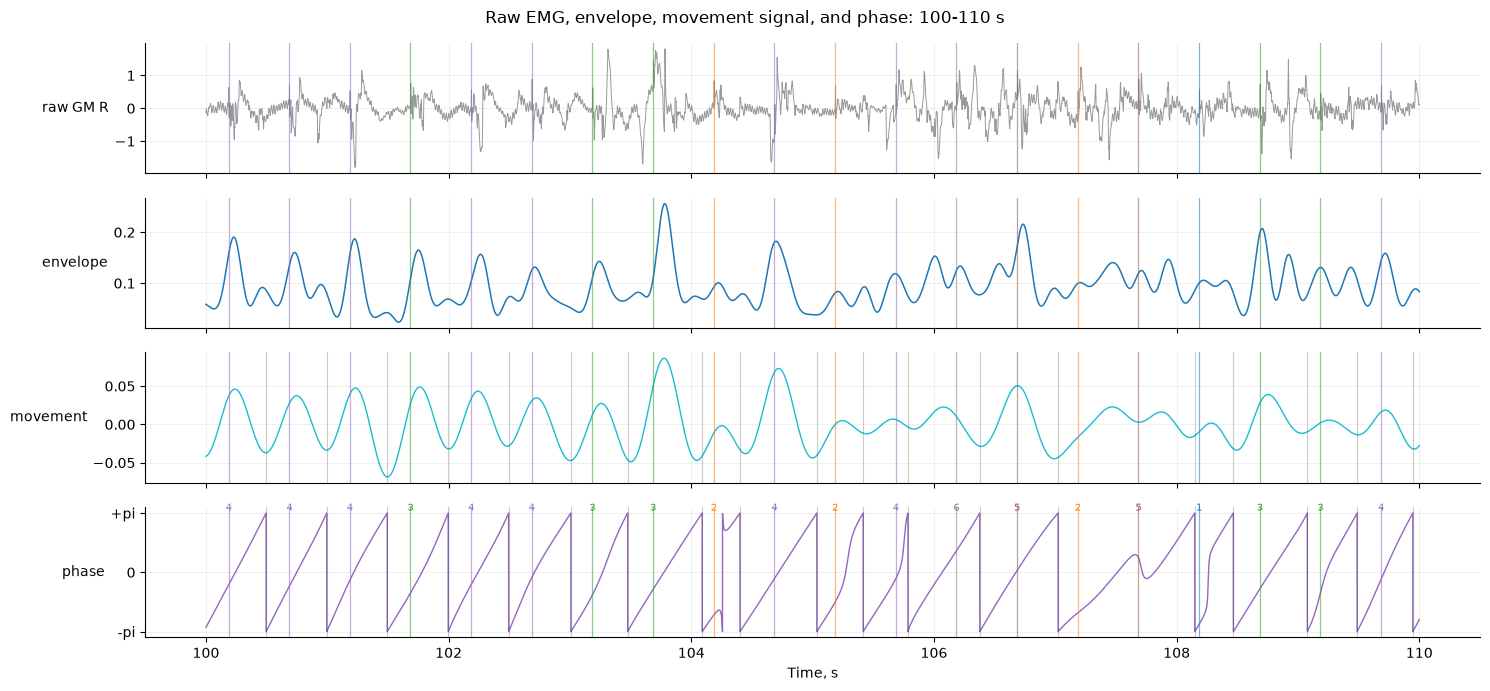

Interpretation: this confirms that each stimulus is assigned to a meaningful continuous movement phase.


In [9]:
qc_start_s, qc_stop_s = movement_phase_config["qc_window_s"]
fig, axes = plot_raw_envelope_phase_segment(
    time_s=time_s,
    raw_emg=raw_emg,
    envelope=envelope,
    movement_signal=movement_signal,
    movement_phase=movement_phase,
    response_by_stim=response_by_stim,
    cycle_boundaries=cycle_boundaries,
    sfreq=sfreq,
    start_s=qc_start_s,
    stop_s=qc_stop_s,
)
plt.show()

print("Interpretation: this confirms that each stimulus is assigned to a meaningful continuous movement phase.")


## QC: Detected Movement-Cycle Periods

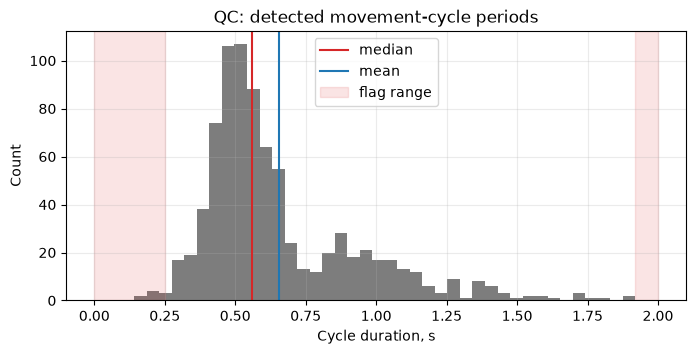

Cycle duration median, s: 0.561
Cycle duration mean, s: 0.6534683313032886
Cycle duration range, s: 0.14175 to 1.9195
Cycles flagged for inspection (<0.25 s or >2.0 s): 8


In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(cycle_duration_s, bins=40, color="0.4", alpha=0.85)
ax.axvline(np.nanmedian(cycle_duration_s), color="tab:red", linewidth=1.5, label="median")
ax.axvline(np.nanmean(cycle_duration_s), color="tab:blue", linewidth=1.5, label="mean")
ax.axvspan(0, cycle_duration_flag_range_s[0], color="tab:red", alpha=0.12, label="flag range")
ax.axvspan(cycle_duration_flag_range_s[1], np.nanmax(cycle_duration_s), color="tab:red", alpha=0.12)
ax.set_xlabel("Cycle duration, s")
ax.set_ylabel("Count")
ax.set_title("QC: detected movement-cycle periods")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

print("Cycle duration median, s:", float(np.nanmedian(cycle_duration_s)))
print("Cycle duration mean, s:", float(np.nanmean(cycle_duration_s)))
print("Cycle duration range, s:", float(np.nanmin(cycle_duration_s)), "to", float(np.nanmax(cycle_duration_s)))
print(f"Cycles flagged for inspection (<{cycle_duration_flag_range_s[0]} s or >{cycle_duration_flag_range_s[1]} s):", len(implausible_cycles))


## Main Figure: Late Response vs M-Response

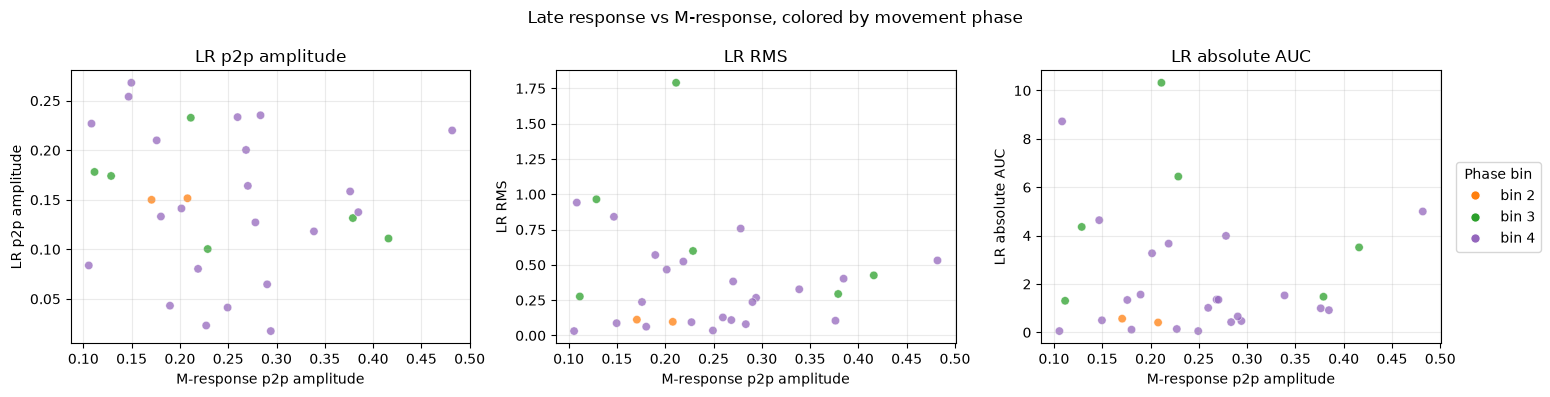

Interpretation: this shows whether stronger M-responses are associated with stronger late responses, and whether this relationship depends on movement phase.


In [11]:
fig, axes = plot_lr_vs_m_response(response_by_stim)
plt.show()

print("Interpretation: this shows whether stronger M-responses are associated with stronger late responses, and whether this relationship depends on movement phase.")


## LR Latency Outliers vs M-Response

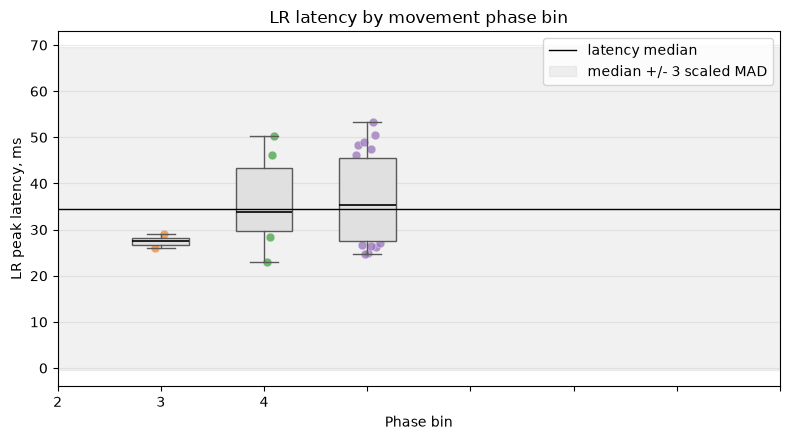

Latency interpretation: latency variation alone is not automatically an artifact. It is suspicious when points are robust outliers, isolated from the main latency cluster, or paired with abnormal waveform/low signal quality.
LR latency outliers shown on graph: 0


,stimulus_index,movement_phase,phase_bin,middle_p2p_amplitude,late_p2p_amplitude,late_peak_latency_ms,late_latency_robust_z


In [12]:
fig, ax, lr_latency_plot_df = plot_lr_latency_outliers(
    response_by_stim,
    latency_center_ms=lr_latency_center_ms,
    latency_scale_ms=lr_latency_scale_ms,
    mad_k=latency_outlier_mad_k,
)
plt.show()

latency_outliers = lr_latency_plot_df.loc[lr_latency_plot_df["late_latency_outlier"]].copy()
print("Latency interpretation: latency variation alone is not automatically an artifact. It is suspicious when points are robust outliers, isolated from the main latency cluster, or paired with abnormal waveform/low signal quality.")
print("LR latency outliers shown on graph:", len(latency_outliers))
display(latency_outliers[[
    "stimulus_index", "movement_phase", "phase_bin", "middle_p2p_amplitude",
    "late_p2p_amplitude", "late_peak_latency_ms", "late_latency_robust_z",
]])


## Phase-Binned Summary: M-Response, LR, And Sample Count

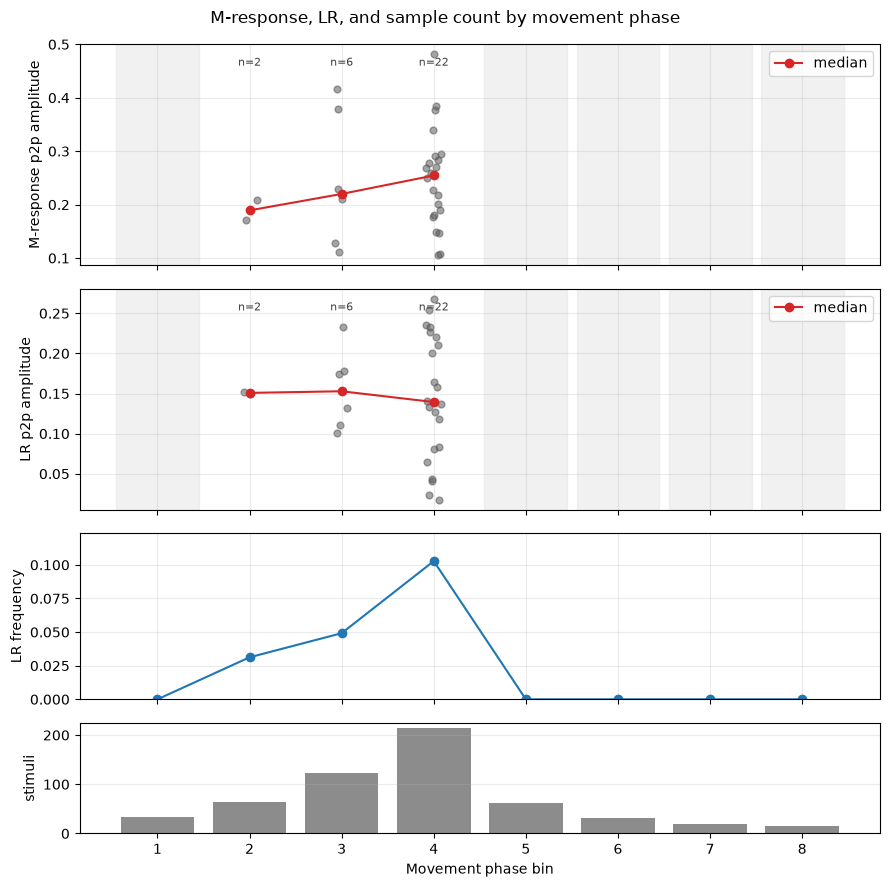

M-response amplitude: shows whether the M-response is stable or changes with movement phase.
LR amplitude: shows whether the late response becomes larger in specific movement phases.
LR frequency: shows whether late responses are more likely in specific movement phases.
Stimulus count: shows whether phase-bin comparisons are well supported.


In [13]:
fig, axes = plot_phase_bin_summary(response_by_stim, response_by_phase_bin)
plt.show()

print("M-response amplitude: shows whether the M-response is stable or changes with movement phase.")
print("LR amplitude: shows whether the late response becomes larger in specific movement phases.")
print("LR frequency: shows whether late responses are more likely in specific movement phases.")
print("Stimulus count: shows whether phase-bin comparisons are well supported.")


## Ten Epoch Examples

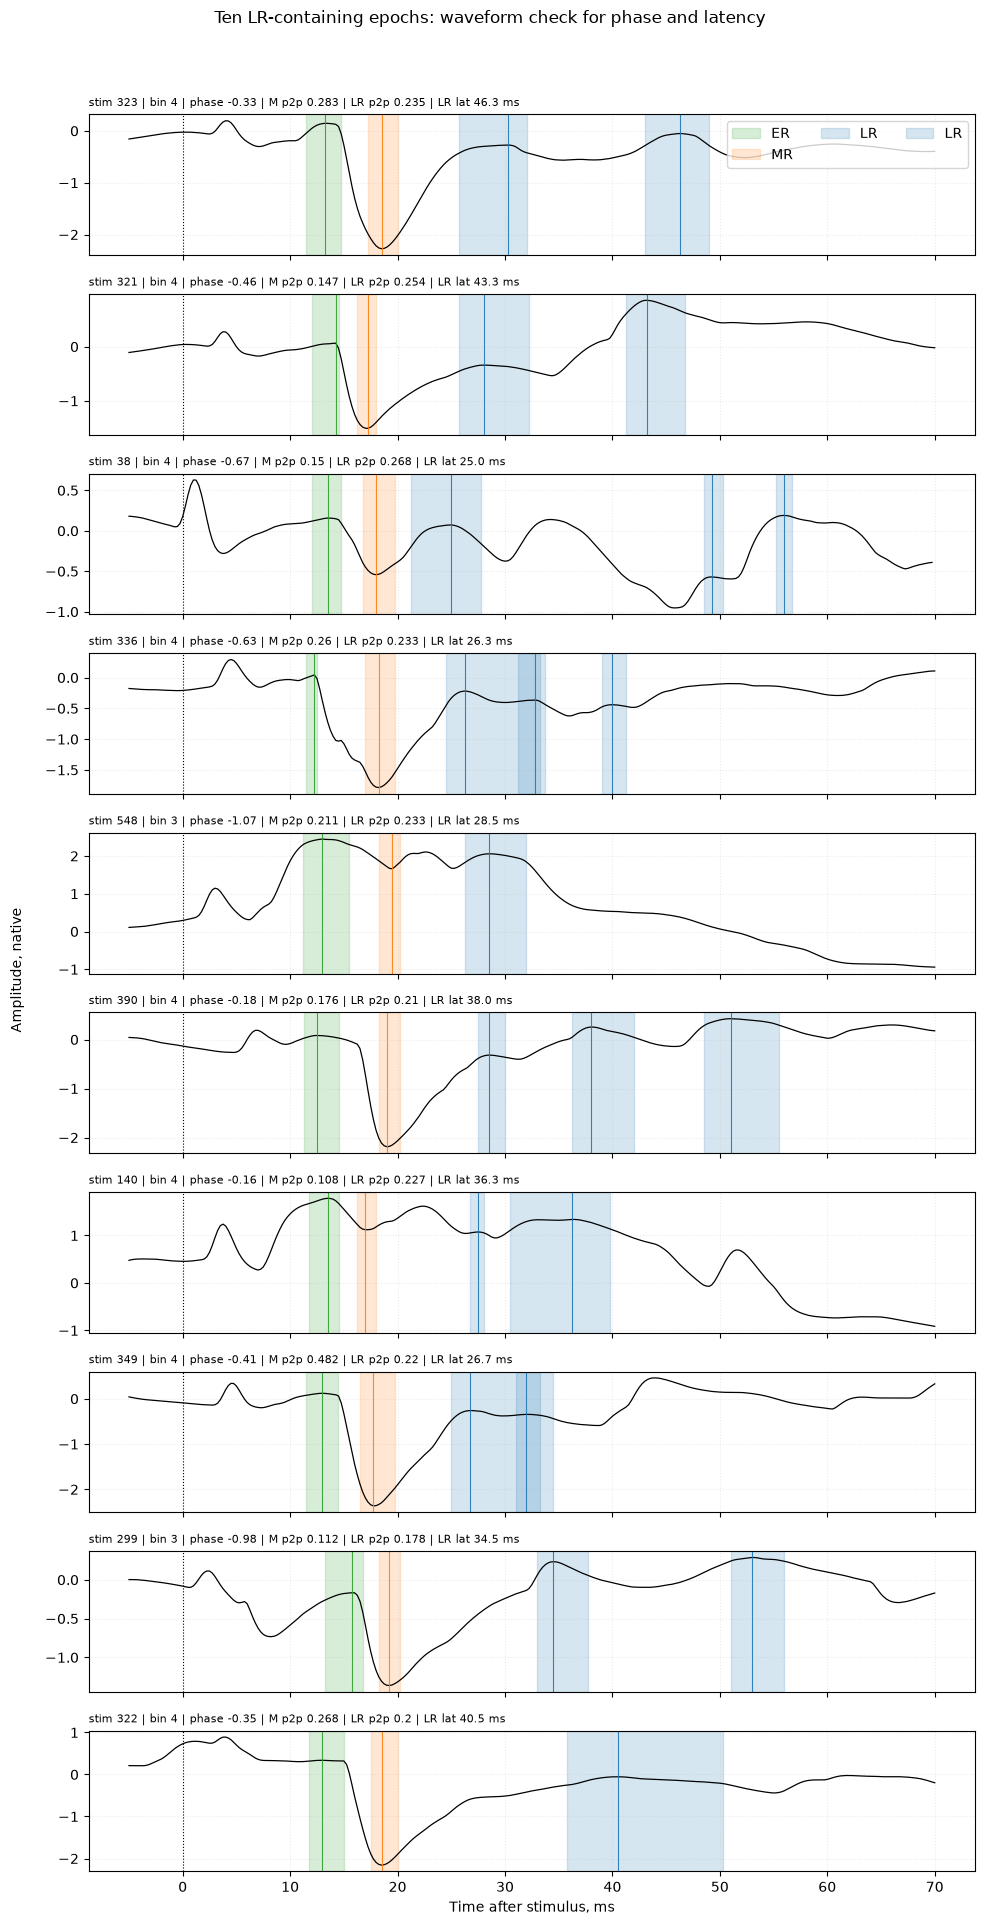

,stimulus_index,stimulus_time_s,movement_phase,phase_bin,middle_p2p_amplitude,late_p2p_amplitude,late_peak_latency_ms,late_latency_outlier,late_count
323,323,300.99125,-0.333848,4,0.283437,0.235312,46.259,False,2
321,321,299.99125,-0.459546,4,0.146875,0.254062,43.259,False,2
38,38,100.18700,-0.673049,4,0.149688,0.268125,25.004,False,3
336,336,307.49100,-0.627421,4,0.259688,0.233438,26.253,False,3
548,548,458.90325,-1.069032,3,0.211250,0.232813,28.491,False,1
390,390,334.48850,-0.182606,4,0.175938,0.210000,38.005,False,3
140,140,151.18375,-0.163004,4,0.108438,0.226875,36.254,False,2
349,349,313.99075,-0.406879,4,0.481875,0.220000,26.747,False,2
299,299,288.99325,-0.977739,3,0.111562,0.178125,34.494,False,2
322,322,300.49125,-0.351488,4,0.268437,0.200313,40.509,False,1


Interpretation: this verifies that dataframe relationships correspond to real visible waveforms.


In [14]:
best_lr_epoch_figure, best_lr_epochs_by_phase = plot_10_epochs_by_phase(
    response_by_stim,
    phase_response_metrics,
    raw_emg,
    time_s,
    sfreq,
    n_plots=10,
)
if best_lr_epoch_figure is not None:
    plt.show()
    display(best_lr_epochs_by_phase[[
        "stimulus_index", "stimulus_time_s", "movement_phase", "phase_bin",
        "middle_p2p_amplitude", "late_p2p_amplitude", "late_peak_latency_ms",
        "late_latency_outlier", "late_count",
    ]])
else:
    print("No LR-containing epochs available for the 10-epoch QC plot.")

print("Interpretation: this verifies that dataframe relationships correspond to real visible waveforms.")


## Distributions Of Metrics

,metric,description,available_values
0,middle_p2p_amplitude,M-response p2p amplitude,30
1,middle_rms,M-response RMS,30
2,middle_peak_latency_ms,M-response peak latency,30
3,late_p2p_amplitude,LR p2p amplitude,30
4,late_rms,LR RMS,30
5,late_auc_abs,LR absolute AUC,30
6,late_peak_latency_ms,LR peak latency,30


p2p_amplitude         absolute_peak_amplitude          \
              count  median                   count  median   
label                                                         
er               30  0.1373                      30  0.3018   
lr               54  0.1020                      54  0.3609   
mr               30  0.2280                      30  1.6568   

      signed_peak_amplitude         prominence         auc_abs           rms  \
                      count  median      count  median   count  median count   
label                                                                          
er                       30  0.2959         30  0.0894      30  0.7362    30   
lr                       54  0.2683         54  0.0923      54  1.0937    54   
mr                       30 -1.5766         30  0.2091      30  3.9426    30   

              start_latency_ms          peak_latency_ms           \
       median            count   median           count   median   
label                                                              
er     0.2555               30  12.0065              30  13.5085   
lr     0.3093               54  32.3790              54  34.2435   
mr     1.5550               30  17.2620              30  18.5050   

      end_latency_ms          duration_ms        amplitude_noise_ratio  \
               count   median       count median                 count   
label                                                                    
er                30  15.0110          30  3.000                    30   
lr                54  35.6215          54  4.125                    54   
mr                30  20.0040          30  2.500                    30   

               p2p_noise_ratio          
        median           count  median  
label                                   
er      3.4845              30  1.3649  
lr      3.7892              54  0.7521  
mr     15.3740              30  2.1062

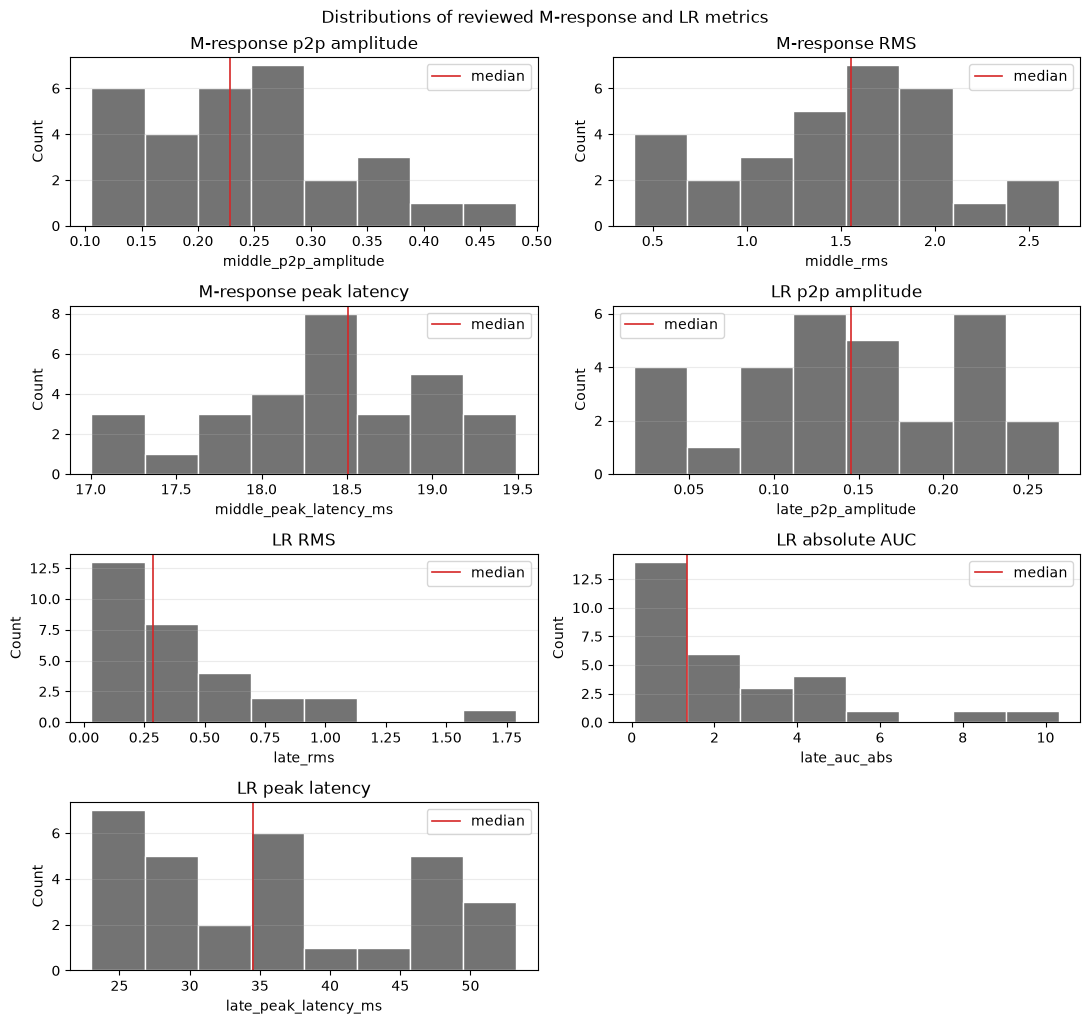

In [15]:
metric_availability = []
for metric_col, description in m_response_metrics + lr_response_metrics:
    metric_availability.append({
        "metric": metric_col,
        "description": description,
        "available_values": int(pd.to_numeric(response_by_stim.get(metric_col, pd.Series(dtype=float)), errors="coerce").notna().sum()),
    })
metric_availability = pd.DataFrame(metric_availability)
display(metric_availability)

display(
    phase_response_metrics.groupby("label")[available_metric_columns]
    .agg(["count", "median"])
    .round(4)
)


distribution_specs = [(metric_col, description) for metric_col, description in m_response_metrics + lr_response_metrics if metric_col in response_by_stim]
if distribution_specs:
    n_cols = 2
    n_rows = int(np.ceil(len(distribution_specs) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, max(2.6 * n_rows, 3.2)), squeeze=False)
    axes = axes.ravel()
    for ax, (metric_col, description) in zip(axes, distribution_specs):
        values = pd.to_numeric(response_by_stim[metric_col], errors="coerce").dropna()
        if values.empty:
            ax.set_title(f"{description} (no data)")
            ax.axis("off")
            continue
        ax.hist(values, bins=min(30, max(8, int(np.sqrt(len(values))))), color="0.45", edgecolor="white")
        ax.axvline(values.median(), color="tab:red", linewidth=1.2, label="median")
        ax.set_title(description)
        ax.set_xlabel(metric_col)
        ax.set_ylabel("Count")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(loc="best")
    for ax in axes[len(distribution_specs):]:
        ax.axis("off")
    fig.suptitle("Distributions of reviewed M-response and LR metrics")
    plt.tight_layout()
    plt.show()
else:
    print("No configured M-response/LR metric columns are available for histograms.")
